In [1]:
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

c:\Users\Sanjog Bhalla\Desktop\Langgraph - CampusX\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
load_dotenv()

True

In [6]:
class SubState(TypedDict):
    
    input_text: str
    translated_text: str

In [4]:
subgraph_llm = ChatOpenAI(model='gpt-4o')

In [8]:
def translate_text(state: SubState):
    
    prompt = f"""Translate the following text to Hindi. Keep it natural and clear. Do not add extra content. Text: {state['input_text']}""".strip()
    
    translated_text = subgraph_llm.invoke(prompt)
    return {"translated_text": translated_text} 

In [9]:
# Now we build the Subgraph
subgraph = StateGraph(SubState)

# Adding the nodes to the subgraph
subgraph.add_node('translate_text', translate_text)

# Making the edges

subgraph.add_edge(START, 'translate_text')
subgraph.add_edge('translate_text', END)

# Compile the subgraph
subgraph = subgraph.compile()

In [10]:
class ParentState(TypedDict):
    
    question: str
    answer_eng: str
    answer_hindi: str

In [11]:
parent_llm = ChatOpenAI(model='gpt-4o-mini')

In [13]:
def generate_answer(state: ParentState):
    
    prompt = f"""Answer the following question in English. Question: {state['question']}""".strip()
    
    answer_eng = parent_llm.invoke(prompt)
    return {"answer_eng": answer_eng}

In [14]:
def translate_answer(state: ParentState):
    
    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hindi': result['translated_text']}

In [15]:
# Build the parent graph
parent_graph = StateGraph(ParentState)

# Add nodes to the parent graph
parent_graph.add_node('generate_answer', generate_answer)
parent_graph.add_node('translate_answer', translate_answer)

# make the edges
parent_graph.add_edge(START, 'generate_answer')
parent_graph.add_edge('generate_answer', 'translate_answer')
parent_graph.add_edge('translate_answer', END)

# Compile the parent graph
parent_graph = parent_graph.compile()

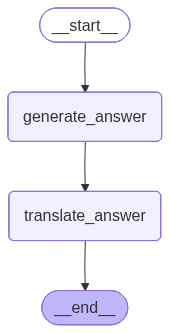

In [16]:
parent_graph

In [17]:
parent_graph.invoke({'question': "What is quantum physics?"})

{'question': 'What is quantum physics?',
 'answer_eng': AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental branch of physics that studies the behavior of matter and energy at the smallest scales, typically at the level of atoms and subatomic particles. It contrasts with classical physics, which describes the macroscopic world in terms of deterministic laws.\n\nKey principles of quantum physics include:\n\n1. **Wave-Particle Duality**: Particles, such as electrons and photons, exhibit both wave-like and particle-like properties. This means they can display behavior characteristic of waves (such as interference) as well as particles (localized in space).\n\n2. **Quantization**: Energy, momentum, and other properties of particles are quantized, meaning they can only take on discrete values rather than a continuous range. For example, electrons in an atom occupy specific energy levels.\n\n3. **Uncertainty Principle**: Formulated by Werner Heisenberg, this